<a href="https://colab.research.google.com/github/PedroPK/TradingWithData/blob/main/10_Trading_com_Dados_IBOV_em_Dolar%2C_IPCA_e_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

01) Instalar e Importar Bibliotecas
- Yahoo Finance
- Pandas
- MatPlot

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

02) Definindo o Período de Análise

In [ ]:
import datetime

start_date    = '2023-01-01'
start_date_br = '01/01/2023'

today = datetime.date.today()

# Formatos comuns:
today_date_br = today.strftime("%d/%m/%Y")  # Dia/Mês/Ano (ex: 27/10/2024)
today_date = today.strftime("%Y-%m-%d")  # Ano-Mês-Dia (ex: 2024-10-27) - Formato ISO 8601
#data_formatada_3 = today.strftime("%d de %B de %Y")  # Dia de Mês de Ano (ex: 27 de Outubro de 2024)
#data_formatada_4 = today.strftime("%A, %d de %B de %Y") # Dia da semana, dia de mês de ano (ex: Domingo, 27 de Outubro de 2024)


#print(today_date)
#print(today_date_br)
#print(data_formatada_3)
#print(data_formatada_4)

03) Extração de Séries Históricas de Dados:
- Série Histórica do IBOV
- Série Histórica da Cotação do Dolar em Reais

In [ ]:
import yfinance as yf

# Obter a cotação do Bitcoin em USD
bitcoin = yf.Ticker("BTC-USD")
btc_usd = bitcoin.history(period="1d")['Close'].iloc[-1]

# Obter a cotação do Dólar em relação ao Real (USD-BRL)
dolar = yf.Ticker("USDBRL=X")
usd_brl = dolar.history(period="1d")['Close'].iloc[-1]

# Calcular a cotação do Bitcoin em BRL
btc_brl = btc_usd * usd_brl

print(f"Cotação do Bitcoin (BTC) em USD: {btc_usd}")
print(f"Cotação do Dólar (USD) em BRL: {usd_brl}")
print(f"Cotação do Bitcoin (BTC) em BRL: {btc_brl}")


Cotação do Bitcoin (BTC) em USD: 106626.84375
Cotação do Dólar (USD) em BRL: 5.65910005569458
Cotação do Bitcoin (BTC) em BRL: 603411.9774041623


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pygments.token import STANDARD_TYPES
import pandas_datareader as pdr


ibov_ticker = '^BVSP'
divo11_ticker = 'DIVO11.SA'
usd_brl_ticker = 'USDBRL=X'

bitcoin_usd_ticker = 'BTC-USD'


ibov_dat = yf.Ticker(ibov_ticker)
divo11_ticker = yf.Ticker(divo11_ticker)

# Obter dados do Bitcoin
bitcoin_usd = yf.Ticker(bitcoin_usd_ticker)

#ibov_download     = yf.download(ibov_ticker, start=start_date, end=today_date,)
#print(ibov_download)

ibov_dataframe         = yf.download(ibov_ticker,        start=start_date,   end=today_date)['Close']
usd_brl_dataframe      = yf.download(usd_brl_ticker,     start=start_date,   end=today_date)['Close']
bitcoin_usd_dataframe  = yf.download(bitcoin_usd_ticker, start=start_date,   end=today_date)['Close']

print(bitcoin_usd_dataframe)

usd_brl_dataframe.rename(columns={"Close": "USDBRL=X"}, inplace=True)
bitcoin_usd_dataframe.rename(columns={"Close": "BTC-USD"}, inplace=True)

# Alinhar os índices antes da multiplicação
#usd_brl_dataframe = usd_brl_dataframe.reindex(bitcoin_usd_dataframe.index, method="ffill")


# Garantir que ambas as séries têm a mesma frequência de dias úteis
#usd_brl_dataframe     = usd_brl_dataframe.resample("D").ffill()  # Preenche dias ausentes com último valor disponível
#bitcoin_usd_dataframe = bitcoin_usd_dataframe.resample("D").ffill()

# Garantir que ambas as séries tenham os mesmos índices (preenchendo valores ausentes)
bitcoin_usd_dataframe = bitcoin_usd_dataframe.asfreq("D", method="ffill")
usd_brl_dataframe     = usd_brl_dataframe.asfreq("D", method="ffill")

# Juntar os dois DataFrames para garantir alinhamento perfeito
merged_df = bitcoin_usd_dataframe.join(usd_brl_dataframe, how="inner")

# Multiplicar para obter o preço do Bitcoin em BRL
merged_df["BTC-BRL"] = merged_df["BTC-USD"] * merged_df["USDBRL=X"]

# Mostrar os primeiros valores
print("")
print(merged_df[["BTC-BRL"]].dropna().head())


#print("")
#print(usd_brl_dataframe.columns)
#print(type(usd_brl_dataframe["USDBRL=X"]))
#print(usd_brl_dataframe["USDBRL=X"])
#print(bitcoin_usd_dataframe)

#bitcoin_brl_dataframe  = bitcoin_usd_dataframe * usd_brl_dataframe

#print(bitcoin_brl_dataframe)

# Mostrar o resultado
#print("")
#print(bitcoin_brl_dataframe.dropna().head())  # Exibir as primeiras cotações do Bitcoin em BRL


#print(ibov_data)
#print(usd_brl_data)
#print(bitcoin_usd_data)
#print(bitcoin_brl_data

#print(ibov_data)
#print(usd_brl_data)
#print(bitcoin_data)

# Obtendo dados históricos
#historico_divo11 = divo11_ticker.history(period="10y") # Obtém dados dos últimos 10 anos
#print(historico_divo11)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Ticker            BTC-USD
Date                     
2023-01-01   16625.080078
2023-01-02   16688.470703
2023-01-03   16679.857422
2023-01-04   16863.238281
2023-01-05   16836.736328
...                   ...
2025-05-16  103489.289062
2025-05-17  103191.085938
2025-05-18  106446.007812
2025-05-19  105606.179688
2025-05-20  106791.085938

[871 rows x 1 columns]

Ticker           BTC-BRL
Date                    
2023-01-02  88206.912729
2023-01-03  89406.217288
2023-01-04  92385.249058
2023-01-05  91425.161332
2023-01-06  90689.644281


03.1) Transformação das Séries em DataFrames

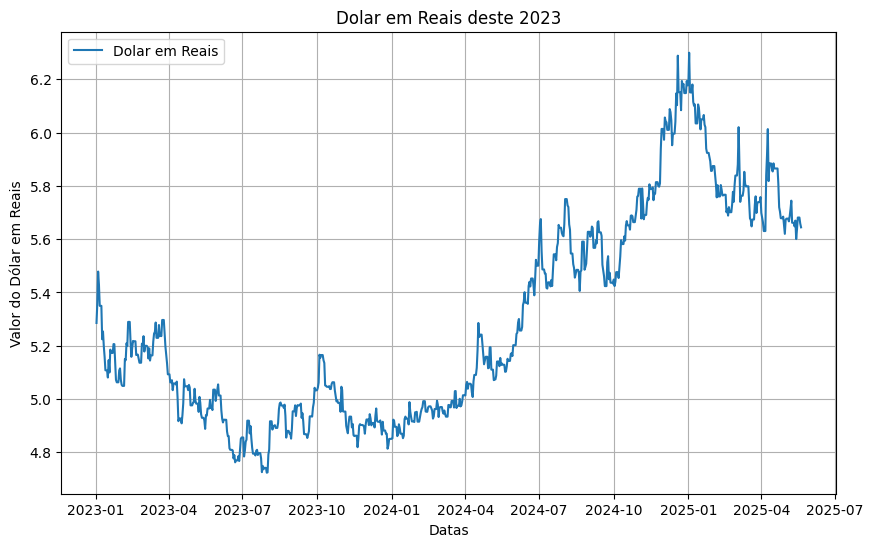

In [ ]:
# IBOV
ibov_dataframe = pd.DataFrame(ibov_dataframe)
ibov_dataframe.columns = ['IBOV']
#print(ibov_df['IBOV'].dtype)


#ifix_df = pd.DataFrame(ifix_data)
#ifix_df.columns = ['IFIX']
#print(ifix_df['IFIX'].dtype)

# USD vs. BRL
usd_brl_dataframe = pd.DataFrame(usd_brl_dataframe)
usd_brl_dataframe.columns = ['USDBRL']
#print(usd_brl_df['USDBRL'])

bitcoin_usd_dataframe = pd.DataFrame(bitcoin_usd_dataframe)
bitcoin_usd_dataframe.columns = ['BTC_USD']
#print(bitcoin_usd_df['BTC_USD'])

plt.figure(figsize=(10,6))
plt.plot(
    usd_brl_dataframe.index,
    usd_brl_dataframe['USDBRL'],
    label='Dolar em Reais'
)
plt.xlabel('Datas')
plt.ylabel('Valor do Dólar em Reais')
plt.title('Dolar em Reais deste ' + start_date[:4])
plt.legend()
plt.grid(True)
plt.show()

03.2) Vendo Amostras dos dados dos DataFrames do IBOV, IFIX e do Dolar-Real

In [ ]:
#ibov_df.head()
# ibov_df.tail()

In [ ]:
# ifix_df.head()
# ifix_df.tail()

In [ ]:
#ifix_df.tail()

In [ ]:
#usd_brl_df.head()

04) Join dos DataFrames do IBOV e IFIX com o do Dolar, sanando os dias com falta de negociação

In [ ]:
ibov_usd = pd.merge(
    ibov_dataframe,
    usd_brl_dataframe,
    left_index=True,
    right_index=True,
    how='inner'
)

'''ifix_usd = pd.merge(
    ifix_df,
    usd_brl_df,
    left_index=True,
    right_index=True,
    how='inner'
)
'''

"ifix_usd = pd.merge(\n    ifix_df,\n    usd_brl_df,\n    left_index=True,\n    right_index=True,\n    how='inner'\n)\n"

05) Calculando a Divisão entre IBOV com o Dolar

In [ ]:
ibov_usd['IBOV_USD'] = ibov_usd['IBOV'] / ibov_usd['USDBRL']

#ifix_usd['IFIX_USD'] = ifix_usd['IFIX'] / ifix_usd['USDBRL']

06) Plotar Gráficoa do IBOV e IFIX em Reais

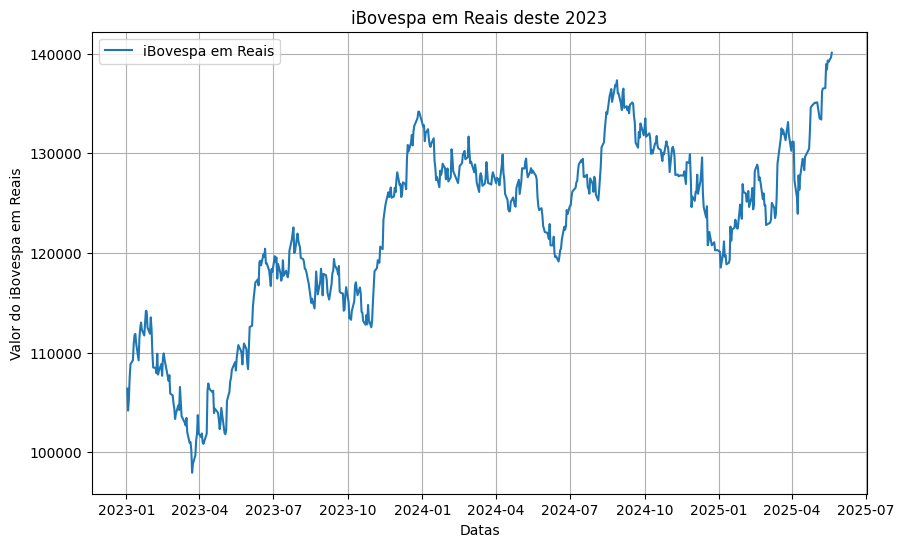

In [ ]:
from sqlalchemy import label

plt.figure(figsize=(10,6))
plt.plot(
    ibov_usd.index,
    ibov_usd['IBOV'],
    label='iBovespa em Reais'
)
plt.xlabel('Datas')
plt.ylabel('Valor do iBovespa em Reais')
plt.title('iBovespa em Reais deste ' + start_date[:4])
plt.legend()
plt.grid(True)
plt.show()

06.1) Plotar Gráficoa do IBOV e IFIX em Dólares

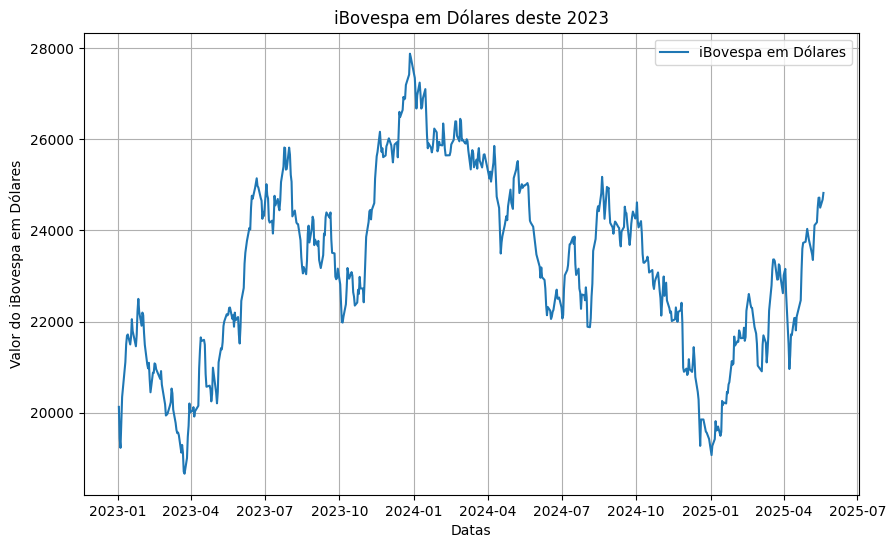

"\nplt.figure(figsize=(10,6))\nplt.plot(\n    ifix_usd.index,\n    ifix_usd['IFIX_USD'],\n    label='iFix em Dólares'\n)\nplt.xlabel('Datas')\nplt.ylabel('Valor do iFix em Dólares')\nplt.title('iFix em Dólares deste ' + start_date[:4])\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(
    ibov_usd.index,
    ibov_usd['IBOV_USD'],
    label='iBovespa em Dólares'
)
plt.xlabel('Datas')
plt.ylabel('Valor do iBovespa em Dólares')
plt.title('iBovespa em Dólares deste ' + start_date[:4])
plt.legend()
plt.grid(True)
plt.show()

'''
plt.figure(figsize=(10,6))
plt.plot(
    ifix_usd.index,
    ifix_usd['IFIX_USD'],
    label='iFix em Dólares'
)
plt.xlabel('Datas')
plt.ylabel('Valor do iFix em Dólares')
plt.title('iFix em Dólares deste ' + start_date[:4])
plt.legend()
plt.grid(True)
plt.show()
'''

07) Plot Comparativo entre iBov em Reais e em Dólares

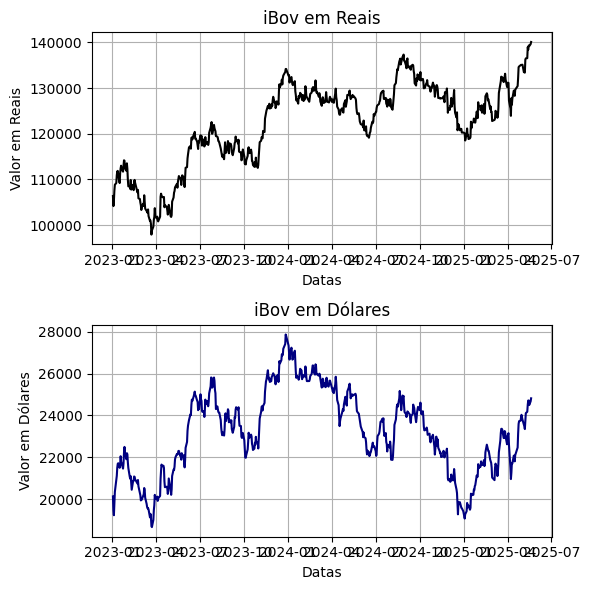

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# 1º Gráfico - iBov em Reais
ax1.plot(
    ibov_usd.index,
    ibov_usd['IBOV'],
    label='IBOV em Reais',
    color='black'
)
ax1.set_xlabel('Datas')
ax1.set_ylabel('Valor em Reais')
ax1.set_title('iBov em Reais')
ax1.grid(True)

# 2º Gráfico - iBov em Dolar
ax2.plot(
    ibov_usd.index,
    ibov_usd['IBOV_USD'],
    label='iBov em Dólar',
    color='navy'
)
ax2.set_xlabel('Datas')
ax2.set_ylabel('Valor em Dólares')
ax2.set_title('iBov em Dólares')
ax2.grid(True)

# Ajuste para evitar Sobreposições
plt.tight_layout()

plt.show()

08) Buscar dados do iBov e cruza-lo com o IPCA

PS: Código gerado pelo Gemini

2025.05.21

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-88-dabbad1fbb80>:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_m = ibov.resample('M').mean()
<ipython-input-88-dabbad1fbb80>:55: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usdbrl_m = usdbrl.resample('M').mean()


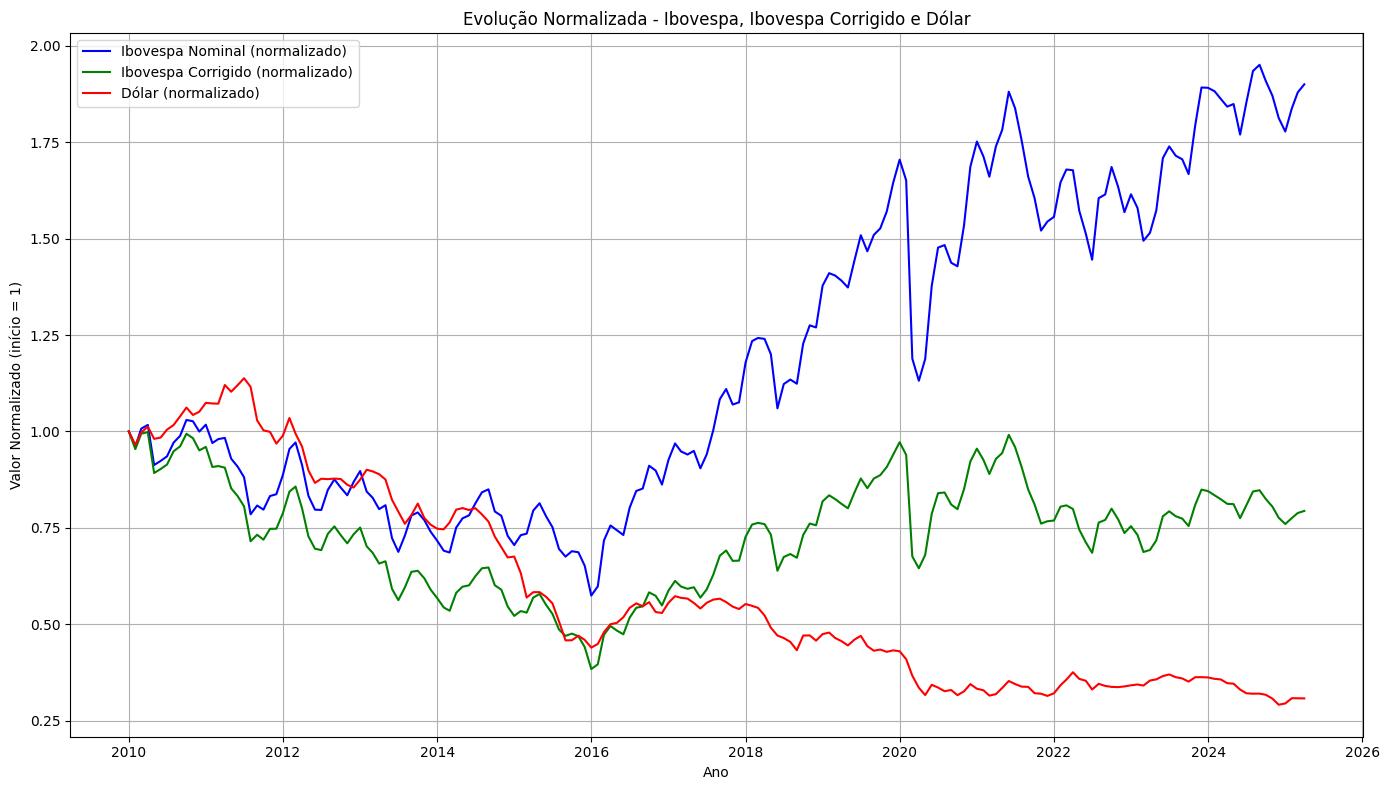

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy matplotlib pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import matplotlib.pyplot as plt

# 1. Buscar dados

ibov = yf.download('^BVSP', start='2010-01-01')['Close']
usdbrl = yf.download('BRL=X', start='2010-01-01')['Close']
usdbrl = 1 / usdbrl  # inverter BRL para USD/BRL

ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)

ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar automaticamente a coluna com data (formato YYYYMM)
data_col = None
for col in ipca_df.columns:
    if ipca_df[col].astype(str).str.match(r'^\d{6}$').any():
        data_col = col
        break

if data_col is None:
    raise ValueError("Coluna com formato de data 'YYYYMM' não encontrada.")

ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])
ipca_df = ipca_df[['date', 'ipca']].sort_values('date').set_index('date')

# 2. Ajustar datas para início do mês
ibov_m = ibov.resample('M').mean()
ibov_m.index = ibov_m.index.to_period('M').to_timestamp()

usdbrl_m = usdbrl.resample('M').mean()
usdbrl_m.index = usdbrl_m.index.to_period('M').to_timestamp()

ipca_df.index = ipca_df.index.to_period('M').to_timestamp()

# 3. Calcular fator acumulado da inflação
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# 4. Consolidar dados
df = pd.concat([ibov_m, usdbrl_m, ipca_df], axis=1)
df.columns = ['Ibovespa', 'USD/BRL', 'IPCA', 'IPCA_Var', 'IPCA_Factor']
df['Ibovespa_Real'] = df['Ibovespa'] / df['IPCA_Factor']
df = df.dropna()

# 5. Normalizar as séries
df_norm = df[['Ibovespa', 'Ibovespa_Real', 'USD/BRL']] / df[['Ibovespa', 'Ibovespa_Real', 'USD/BRL']].iloc[0]

# 6. Gráfico
plt.figure(figsize=(14, 8))
plt.plot(df_norm.index, df_norm['Ibovespa'], label='Ibovespa Nominal (normalizado)', color='blue')
plt.plot(df_norm.index, df_norm['Ibovespa_Real'], label='Ibovespa Corrigido (normalizado)', color='green')
plt.plot(df_norm.index, df_norm['USD/BRL'], label='Dólar (normalizado)', color='red')
plt.title('Evolução Normalizada - Ibovespa, Ibovespa Corrigido e Dólar')
plt.xlabel('Ano')
plt.ylabel('Valor Normalizado (início = 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-94-21210fa46eff>:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_m = ibov.resample('M').mean()
<ipython-input-94-21210fa46eff>:55: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usdbrl_m = usdbrl.resample('M').mean()


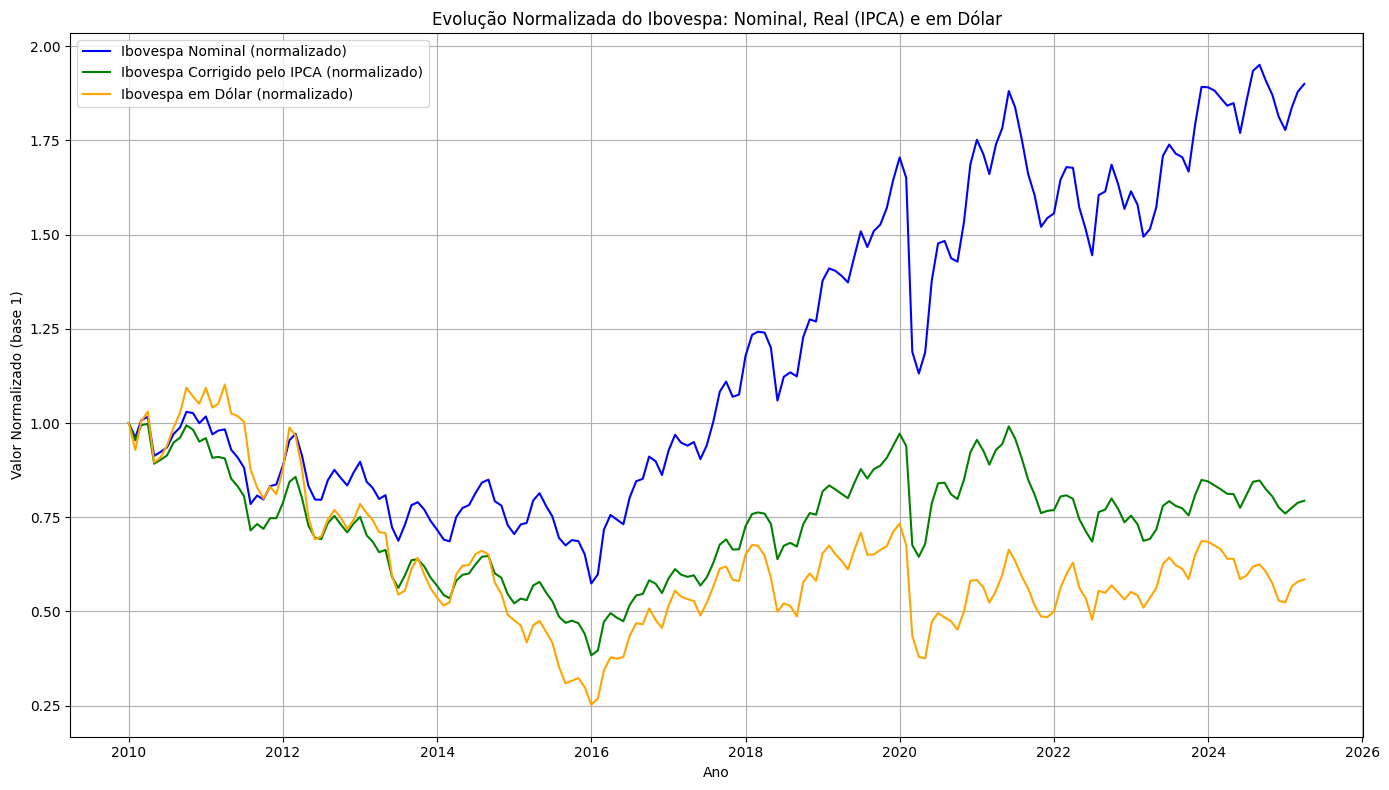

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy matplotlib pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import matplotlib.pyplot as plt

# 1. Buscar dados
start_date = '2010-01-01'

ibov = yf.download('^BVSP', start=start_date)['Close']
usdbrl = yf.download('USDBRL=X', start=start_date)['Close']  # ✅ usar diretamente sem inverter

ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)

ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar automaticamente a coluna com data (formato YYYYMM)
data_col = None
for col in ipca_df.columns:
    if ipca_df[col].astype(str).str.match(r'^\d{6}$').any():
        data_col = col
        break

if data_col is None:
    raise ValueError("Coluna com formato de data 'YYYYMM' não encontrada.")

ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])
ipca_df = ipca_df[['date', 'ipca']].sort_values('date').set_index('date')

# 2. Ajustar datas para início do mês
ibov_m = ibov.resample('M').mean()
ibov_m.index = ibov_m.index.to_period('M').to_timestamp()

usdbrl_m = usdbrl.resample('M').mean()
usdbrl_m.index = usdbrl_m.index.to_period('M').to_timestamp()

ipca_df.index = ipca_df.index.to_period('M').to_timestamp()

# 3. Calcular fator acumulado da inflação
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# 4. Consolidar dados
df = pd.concat([ibov_m, usdbrl_m, ipca_df], axis=1)
df.columns = ['Ibovespa', 'USD/BRL', 'IPCA', 'IPCA_Var', 'IPCA_Factor']
df['Ibovespa_Real'] = df['Ibovespa'] / df['IPCA_Factor']
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']  # ✅ divisão correta
df = df.dropna()

# 5. Normalizar as séries
df_norm = df[['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD']] / df[['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD']].iloc[0]

# 6. Gráfico final
plt.figure(figsize=(14, 8))
plt.plot(df_norm.index, df_norm['Ibovespa'], label='Ibovespa Nominal (normalizado)', color='blue')
plt.plot(df_norm.index, df_norm['Ibovespa_Real'], label='Ibovespa Corrigido pelo IPCA (normalizado)', color='green')
plt.plot(df_norm.index, df_norm['Ibovespa_USD'], label='Ibovespa em Dólar (normalizado)', color='orange')

plt.title('Evolução Normalizada do Ibovespa: Nominal, Real (IPCA) e em Dólar')
plt.xlabel('Ano')
plt.ylabel('Valor Normalizado (base 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import yfinance as yf

btc = yf.download('BTC-USD', start='2010-01-01')['Close']
print('btc.head() = ', btc.head())

print('btc.tail() = ', btc.tail())

[*********************100%***********************]  1 of 1 completed

btc.head() =  Ticker         BTC-USD
Date                  
2014-09-17  457.334015
2014-09-18  424.440002
2014-09-19  394.795990
2014-09-20  408.903992
2014-09-21  398.821014
btc.tail() =  Ticker            BTC-USD
Date                     
2025-05-17  103191.085938
2025-05-18  106446.007812
2025-05-19  105606.179688
2025-05-20  106791.085938
2025-05-21  108392.218750


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-107-f84a7eab695d>:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_m = ibov.resample('M').mean()
<ipython-input-107-f84a7eab695d>:56: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usdbrl_m = usdbrl.resample('M').mean()
<ipython-input-107-f84a7eab695d>:59: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  btc_m = btc.resample('M').mean()


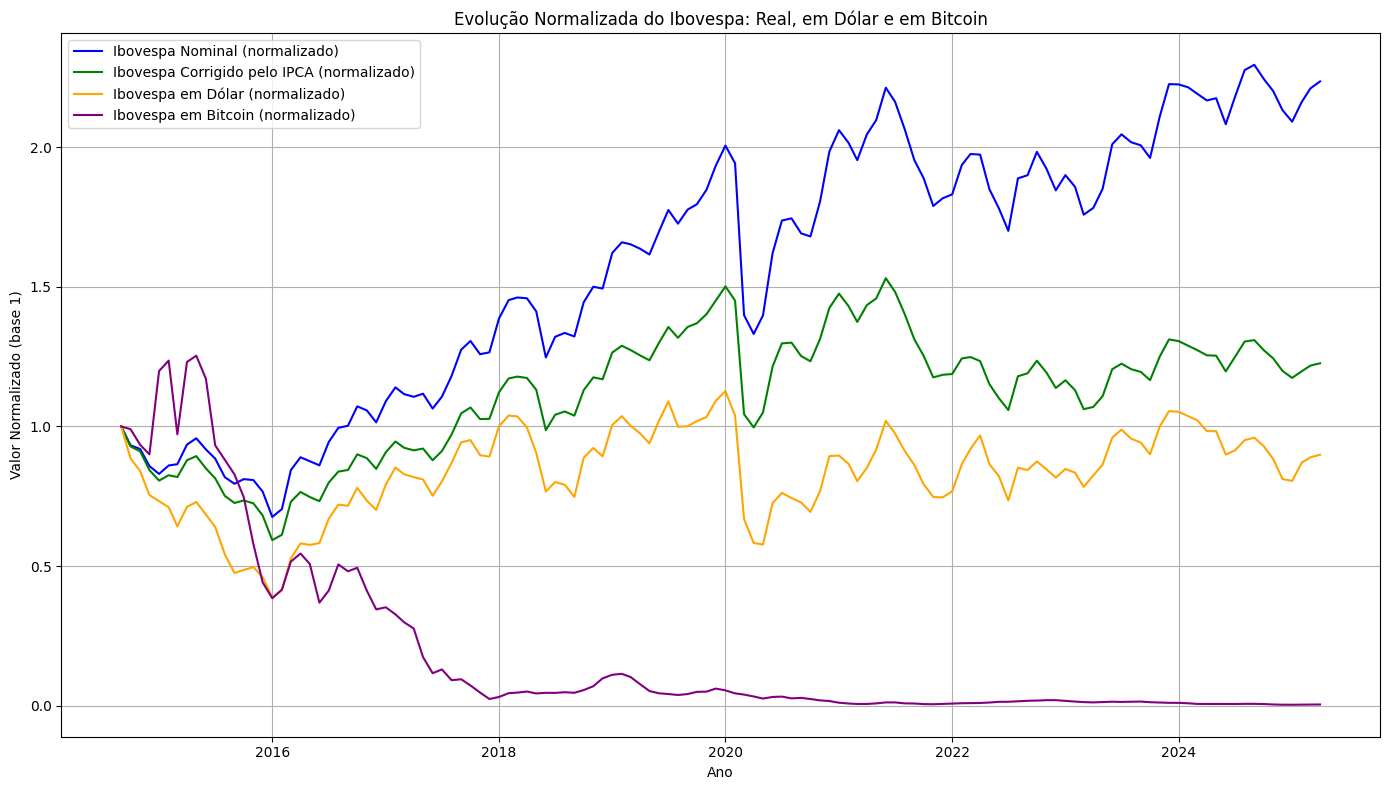

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy matplotlib pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import matplotlib.pyplot as plt

# 1. Buscar dados

ibov = yf.download('^BVSP', start='2014-01-01')['Close']
usdbrl = yf.download('USDBRL=X', start='2014-01-01')['Close']
btc = yf.download('BTC-USD', start='2014-01-01')['Close']  # Bitcoin em USD

# 2. Buscar IPCA
ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)

ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar coluna de data
data_col = None
for col in ipca_df.columns:
    if ipca_df[col].astype(str).str.match(r'^\d{6}$').any():
        data_col = col
        break

if data_col is None:
    raise ValueError("Coluna de data 'YYYYMM' não encontrada.")

ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])
ipca_df = ipca_df[['date', 'ipca']].sort_values('date').set_index('date')

# 3. Ajustar datas para início do mês
ibov_m = ibov.resample('M').mean()
ibov_m.index = ibov_m.index.to_period('M').to_timestamp()

usdbrl_m = usdbrl.resample('M').mean()
usdbrl_m.index = usdbrl_m.index.to_period('M').to_timestamp()

btc_m = btc.resample('M').mean()
btc_m.index = btc_m.index.to_period('M').to_timestamp()

ipca_df.index = ipca_df.index.to_period('M').to_timestamp()

# 4. Calcular inflação acumulada
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# 5. Consolidar dados
df = pd.concat([ibov_m, usdbrl_m, btc_m, ipca_df], axis=1)
df.columns = ['Ibovespa', 'USD/BRL', 'BTC/USD', 'IPCA', 'IPCA_Var', 'IPCA_Factor']

# 6. Calcular as versões corrigidas
df['Ibovespa_Real'] = df['Ibovespa'] / df['IPCA_Factor']
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']
df['Ibovespa_BTC'] = df['Ibovespa_USD'] / df['BTC/USD']  # Corrigido pelo BTC (em dólar)

# 7. Remover valores faltantes
df = df.dropna()

# 8. Normalizar para visualização
df_norm = df[['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD', 'Ibovespa_BTC']] / df[['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD', 'Ibovespa_BTC']].iloc[0]

# 9. Gráfico final
plt.figure(figsize=(14, 8))
plt.plot(df_norm.index, df_norm['Ibovespa'], label='Ibovespa Nominal (normalizado)', color='blue')
plt.plot(df_norm.index, df_norm['Ibovespa_Real'], label='Ibovespa Corrigido pelo IPCA (normalizado)', color='green')
plt.plot(df_norm.index, df_norm['Ibovespa_USD'], label='Ibovespa em Dólar (normalizado)', color='orange')
plt.plot(df_norm.index, df_norm['Ibovespa_BTC'], label='Ibovespa em Bitcoin (normalizado)', color='purple')

plt.title('Evolução Normalizada do Ibovespa: Real, em Dólar e em Bitcoin')
plt.xlabel('Ano')
plt.ylabel('Valor Normalizado (base 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-109-7ac3ad859e1c>:54: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_m = ibov.resample('M').mean()
<ipython-input-109-7ac3ad859e1c>:57: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usdbrl_m = usdbrl.resample('M').mean()
<ipython-input-109-7ac3ad859e1c>:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  btc_m = btc.resample('M').mean()


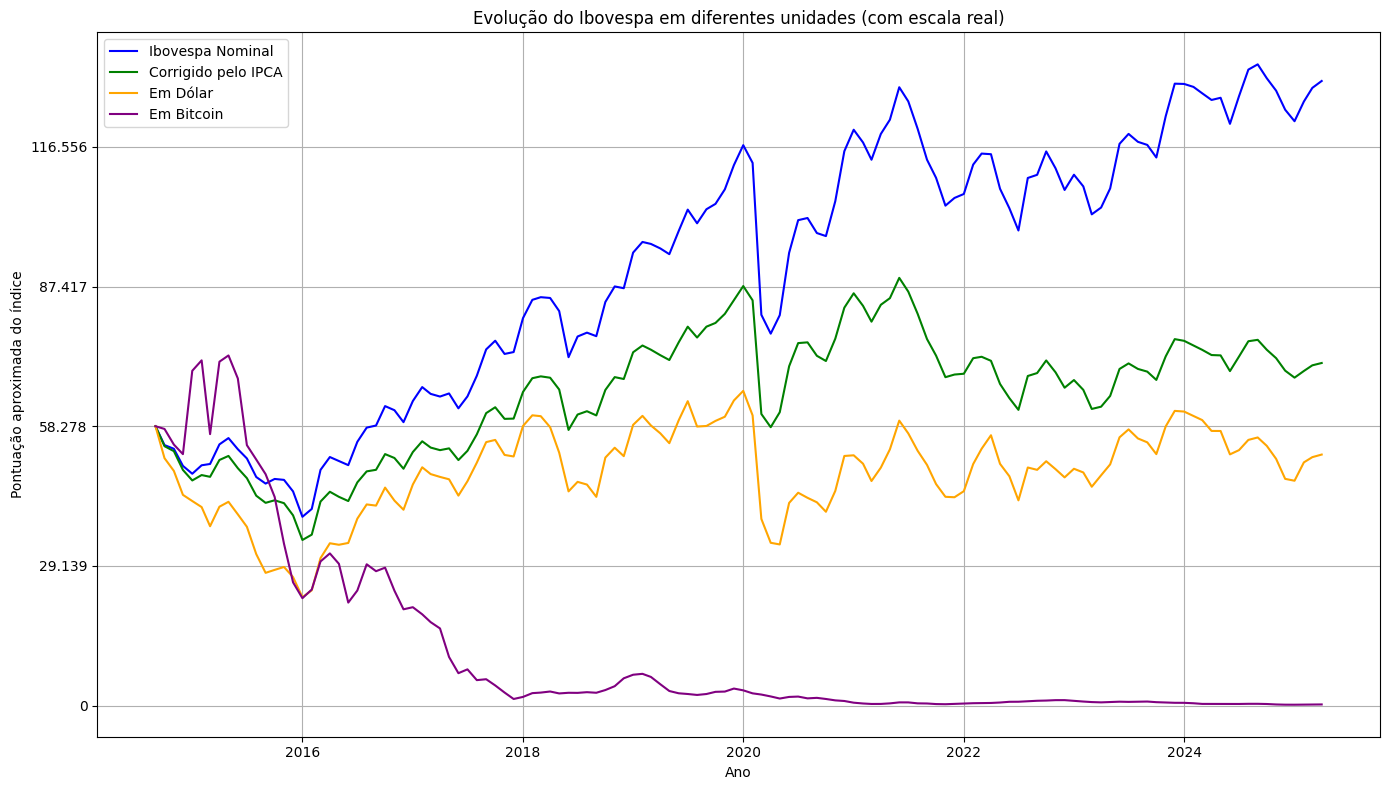

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy matplotlib pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Buscar dados

ibov = yf.download('^BVSP', start='2014-01-01')['Close']
usdbrl = yf.download('USDBRL=X', start='2014-01-01')['Close']
btc = yf.download('BTC-USD', start='2014-01-01')['Close']

# 2. Buscar IPCA
ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)

ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar coluna de data
data_col = None
for col in ipca_df.columns:
    if ipca_df[col].astype(str).str.match(r'^\d{6}$').any():
        data_col = col
        break

if data_col is None:
    raise ValueError("Coluna de data 'YYYYMM' não encontrada.")

ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])
ipca_df = ipca_df[['date', 'ipca']].sort_values('date').set_index('date')

# 3. Ajustar datas para início do mês
ibov_m = ibov.resample('M').mean()
ibov_m.index = ibov_m.index.to_period('M').to_timestamp()

usdbrl_m = usdbrl.resample('M').mean()
usdbrl_m.index = usdbrl_m.index.to_period('M').to_timestamp()

btc_m = btc.resample('M').mean()
btc_m.index = btc_m.index.to_period('M').to_timestamp()

ipca_df.index = ipca_df.index.to_period('M').to_timestamp()

# 4. Calcular inflação acumulada
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# 5. Consolidar dados
df = pd.concat([ibov_m, usdbrl_m, btc_m, ipca_df], axis=1)
df.columns = ['Ibovespa', 'USD/BRL', 'BTC/USD', 'IPCA', 'IPCA_Var', 'IPCA_Factor']

# 6. Calcular versões corrigidas
df['Ibovespa_Real'] = df['Ibovespa'] / df['IPCA_Factor']
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']
df['Ibovespa_BTC'] = df['Ibovespa_USD'] / df['BTC/USD']
df = df.dropna()

# 7. Normalizar
df_norm = df[['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD', 'Ibovespa_BTC']] / df[['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD', 'Ibovespa_BTC']].iloc[0]

# Valor inicial do Ibovespa Nominal
base_value = df['Ibovespa'].iloc[0]

# 8. Gráfico com eixo Y formatado como pontuação do índice
plt.figure(figsize=(14, 8))
plt.plot(df_norm.index, df_norm['Ibovespa'], label='Ibovespa Nominal', color='blue')
plt.plot(df_norm.index, df_norm['Ibovespa_Real'], label='Corrigido pelo IPCA', color='green')
plt.plot(df_norm.index, df_norm['Ibovespa_USD'], label='Em Dólar', color='orange')
plt.plot(df_norm.index, df_norm['Ibovespa_BTC'], label='Em Bitcoin', color='purple')

plt.title('Evolução do Ibovespa em diferentes unidades (com escala real)')
plt.xlabel('Ano')
plt.ylabel('Pontuação aproximada do índice')

# ✅ Formatar eixo Y com base no valor inicial do Ibovespa
formatter = ticker.FuncFormatter(lambda y, _: f'{int(y * base_value):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1-24206101.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download('^BVSP', start='2005-01-01')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1-24206101.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdbrl = yf.download('USDBRL=X', start='2005-01-01')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1-24206101.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2005-01-01')['Close']  # dados só existirão de 2014 em diante
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1-24206101.py:54: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_m = ibov.resample('M').mean()
/tmp/ipython-input-1-24206101.py:57: FutureWarning: 

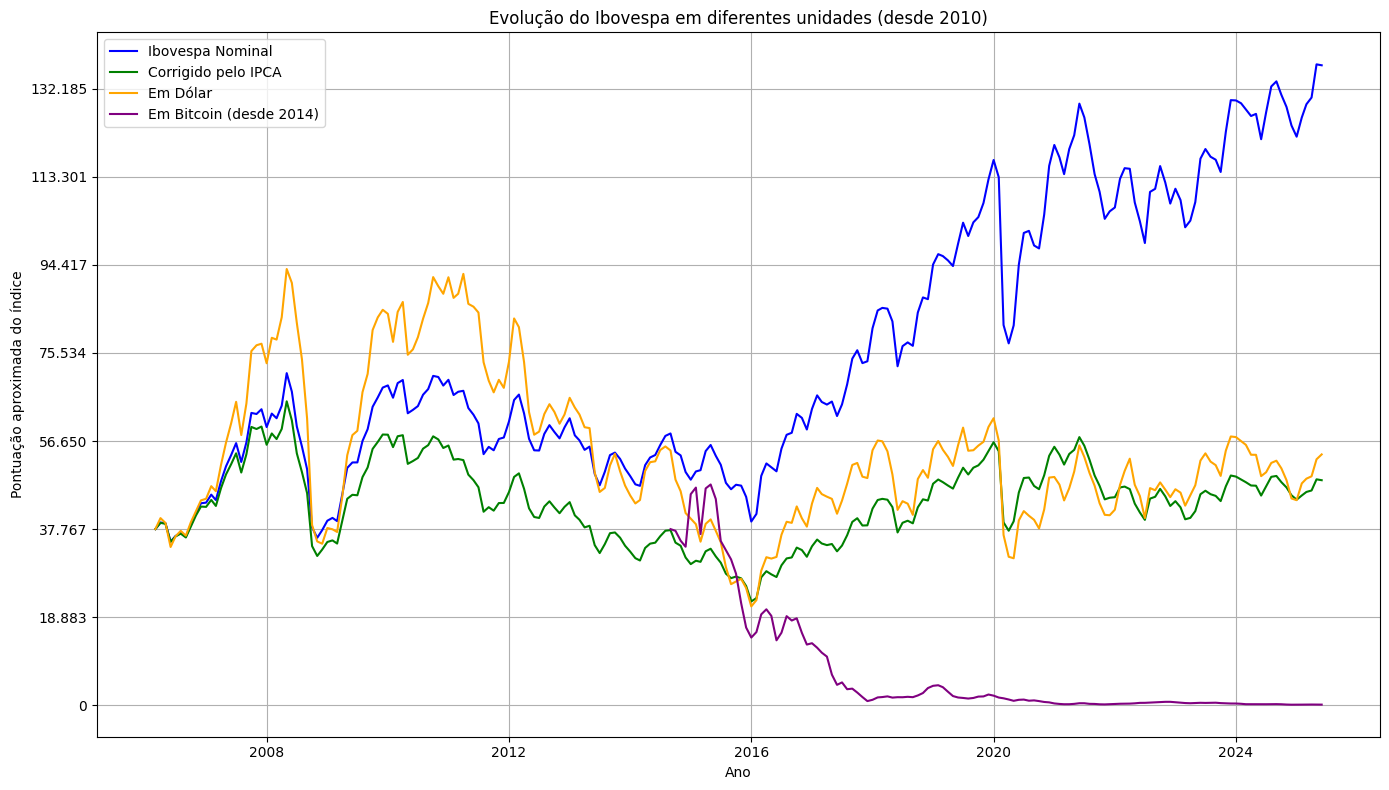

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy matplotlib pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Buscar dados desde 2005

ibov = yf.download('^BVSP', start='2005-01-01')['Close']
usdbrl = yf.download('USDBRL=X', start='2005-01-01')['Close']
btc = yf.download('BTC-USD', start='2005-01-01')['Close']  # dados só existirão de 2014 em diante

# 2. Buscar IPCA
ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)

ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar coluna de data
data_col = None
for col in ipca_df.columns:
    if ipca_df[col].astype(str).str.match(r'^\d{6}$').any():
        data_col = col
        break

if data_col is None:
    raise ValueError("Coluna de data 'YYYYMM' não encontrada.")

ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])
ipca_df = ipca_df[['date', 'ipca']].sort_values('date').set_index('date')

# 3. Ajustar datas para início do mês
ibov_m = ibov.resample('M').mean()
ibov_m.index = ibov_m.index.to_period('M').to_timestamp()

usdbrl_m = usdbrl.resample('M').mean()
usdbrl_m.index = usdbrl_m.index.to_period('M').to_timestamp()

btc_m = btc.resample('M').mean()
btc_m.index = btc_m.index.to_period('M').to_timestamp()

ipca_df.index = ipca_df.index.to_period('M').to_timestamp()

# 4. Calcular inflação acumulada
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# 5. Consolidar dados
df = pd.concat([ibov_m, usdbrl_m, btc_m, ipca_df], axis=1)
df.columns = ['Ibovespa', 'USD/BRL', 'BTC/USD', 'IPCA', 'IPCA_Var', 'IPCA_Factor']

# 6. Calcular versões corrigidas
df['Ibovespa_Real'] = df['Ibovespa'] / df['IPCA_Factor']
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']
df['Ibovespa_BTC'] = df['Ibovespa_USD'] / df['BTC/USD']  # só terá valor de 2014 em diante
df = df.dropna(subset=['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD'])

# 7. Normalização
df_norm = pd.DataFrame(index=df.index)
df_norm['Ibovespa'] = df['Ibovespa'] / df['Ibovespa'].iloc[0]
df_norm['Ibovespa_Real'] = df['Ibovespa_Real'] / df['Ibovespa_Real'].iloc[0]
df_norm['Ibovespa_USD'] = df['Ibovespa_USD'] / df['Ibovespa_USD'].iloc[0]

# ⚠️ Normalizar BTC apenas a partir da primeira data válida
if df['Ibovespa_BTC'].notna().any():
    first_valid_idx = df['Ibovespa_BTC'].first_valid_index()
    base_btc = df.loc[first_valid_idx, 'Ibovespa_BTC']
    df_norm['Ibovespa_BTC'] = df['Ibovespa_BTC'] / base_btc
else:
    df_norm['Ibovespa_BTC'] = None

# Valor inicial do Ibovespa Nominal (para formatar eixo Y)
base_value = df['Ibovespa'].iloc[0]

# 8. Gráfico final
plt.figure(figsize=(14, 8))

plt.plot(df_norm.index, df_norm['Ibovespa'], label='Ibovespa Nominal', color='blue')
plt.plot(df_norm.index, df_norm['Ibovespa_Real'], label='Corrigido pelo IPCA', color='green')
plt.plot(df_norm.index, df_norm['Ibovespa_USD'], label='Em Dólar', color='orange')
plt.plot(df_norm.index, df_norm['Ibovespa_BTC'], label='Em Bitcoin (desde 2014)', color='purple')

plt.title('Evolução do Ibovespa em diferentes unidades (desde 2010)')
plt.xlabel('Ano')
plt.ylabel('Pontuação aproximada do índice')

# Formatar o eixo Y com base no valor real do índice
formatter = ticker.FuncFormatter(lambda y, _: f'{int(y * base_value):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-5-834998ebbb87>:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ibov_m = ibov.resample('M').mean()
<ipython-input-5-834998ebbb87>:49: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usdbrl_m = usdbrl.resample('M').mean()
<ipython-input-5-834998ebbb87>:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  btc_m = btc.resample('M').mean()


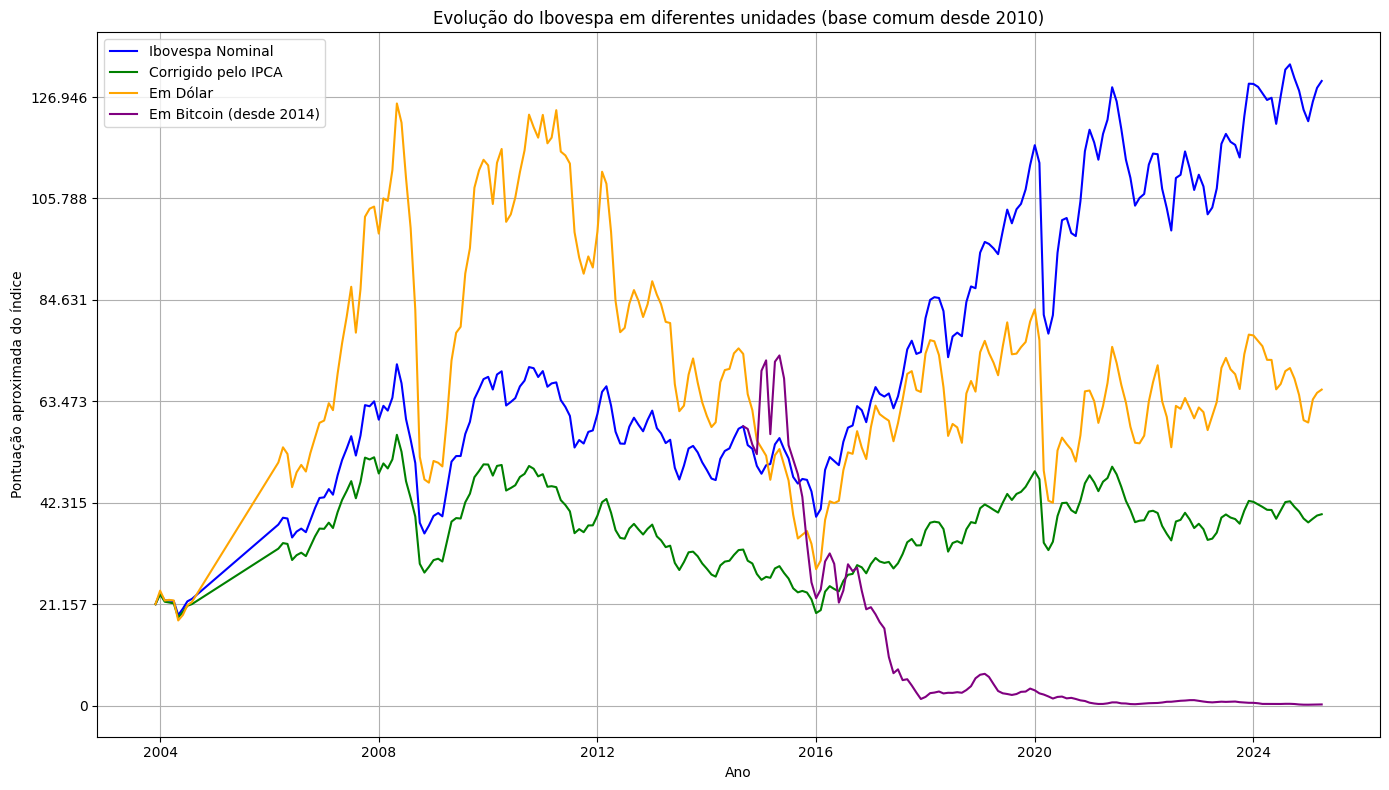

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy matplotlib pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Buscar dados desde 2002
ibov = yf.download('^BVSP', start='2002-01-01')['Close']
usdbrl = yf.download('USDBRL=X', start='2002-01-01')['Close']
btc = yf.download('BTC-USD', start='2002-01-01')['Close']  # dados a partir de 2014

# 2. Buscar IPCA
ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)

ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar coluna de data
data_col = next(col for col in ipca_df.columns if ipca_df[col].astype(str).str.match(r'^\d{6}$').any())

ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])
ipca_df = ipca_df[['date', 'ipca']].sort_values('date').set_index('date')

# 3. Ajustar datas para início do mês
ibov_m = ibov.resample('M').mean()
ibov_m.index = ibov_m.index.to_period('M').to_timestamp()

usdbrl_m = usdbrl.resample('M').mean()
usdbrl_m.index = usdbrl_m.index.to_period('M').to_timestamp()

btc_m = btc.resample('M').mean()
btc_m.index = btc_m.index.to_period('M').to_timestamp()

ipca_df.index = ipca_df.index.to_period('M').to_timestamp()

# 4. Calcular inflação acumulada
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# 5. Consolidar dados
df = pd.concat([ibov_m, usdbrl_m, btc_m, ipca_df], axis=1)
df.columns = ['Ibovespa', 'USD/BRL', 'BTC/USD', 'IPCA', 'IPCA_Var', 'IPCA_Factor']

# 6. Calcular versões corrigidas
df['Ibovespa_Real'] = df['Ibovespa'] / df['IPCA_Factor']
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']
df['Ibovespa_BTC'] = df['Ibovespa_USD'] / df['BTC/USD']
df = df.dropna(subset=['Ibovespa', 'Ibovespa_Real', 'Ibovespa_USD'])

# 7. Normalização com base de 2010
df_norm = pd.DataFrame(index=df.index)
df_norm['Ibovespa'] = df['Ibovespa'] / df['Ibovespa'].iloc[0]
df_norm['Ibovespa_Real'] = df['Ibovespa_Real'] / df['Ibovespa_Real'].iloc[0]
df_norm['Ibovespa_USD'] = df['Ibovespa_USD'] / df['Ibovespa_USD'].iloc[0]

# ✅ Correção: alinhar o Ibov em BTC com o valor real do Ibovespa no início de 2014
if df['Ibovespa_BTC'].notna().any():
    first_btc_idx = df['Ibovespa_BTC'].first_valid_index()
    base_btc_value = df['Ibovespa_BTC'].loc[first_btc_idx]
    base_ibov_nominal = df['Ibovespa'].loc[first_btc_idx]
    base_ibov_visual = df['Ibovespa'].iloc[0]

    # Escalar a curva para que ela entre alinhada com a escala do gráfico
    df_norm['Ibovespa_BTC'] = (df['Ibovespa_BTC'] / base_btc_value) * (base_ibov_nominal / base_ibov_visual)
else:
    df_norm['Ibovespa_BTC'] = None

# Valor inicial do Ibovespa (para o eixo Y formatado)
base_value = df['Ibovespa'].iloc[0]

# 8. Gráfico final
plt.figure(figsize=(14, 8))

plt.plot(df_norm.index, df_norm['Ibovespa'], label='Ibovespa Nominal', color='blue')
plt.plot(df_norm.index, df_norm['Ibovespa_Real'], label='Corrigido pelo IPCA', color='green')
plt.plot(df_norm.index, df_norm['Ibovespa_USD'], label='Em Dólar', color='orange')
plt.plot(df_norm.index, df_norm['Ibovespa_BTC'], label='Em Bitcoin (desde 2014)', color='purple')

plt.title('Evolução do Ibovespa em diferentes unidades (base comum desde 2010)')
plt.xlabel('Ano')
plt.ylabel('Pontuação aproximada do índice')

# ✅ Eixo Y formatado como pontuação real do Ibovespa
formatter = ticker.FuncFormatter(lambda y, _: f'{int(y * base_value):,}'.replace(',', '.'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2025.05.26 - Usando o PlotLy

In [ ]:
# Instalar bibliotecas
!pip install yfinance sidrapy plotly pandas

# Imports
import yfinance as yf
import sidrapy
import pandas as pd
import plotly.graph_objects as go

# 1. Buscar dados diários desde 2010
ibov = yf.download('^BVSP', start='2010-01-01')
usdbrl = yf.download('USDBRL=X', start='2010-01-01')
btc = yf.download('BTC-USD', start='2010-01-01')

# 2. Forçar uso da coluna 'Close' corretamente
ibov = ibov['Close'] if 'Close' in ibov.columns else ibov.squeeze()
usdbrl = usdbrl['Close'] if 'Close' in usdbrl.columns else usdbrl.squeeze()
btc = btc['Close'] if 'Close' in btc.columns else btc.squeeze()

# 3. Buscar IPCA mensal via SIDRA
ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)
ipca_df = pd.DataFrame(ipca_data)

# Remover cabeçalho duplicado
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

# Detectar coluna de data
data_col = next(col for col in ipca_df.columns if ipca_df[col].astype(str).str.match(r'^\d{6}$').any())
ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')

# Tratar valores
ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])

# Calcular fator acumulado da inflação
ipca_df = ipca_df[['date', 'ipca']].sort_values('date')
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# Expandir IPCA mensal para diário
ipca_df = ipca_df.set_index('date').resample('D').ffill()

# 4. Consolidar todos os dados com segurança
df = pd.concat([
    pd.DataFrame(ibov.squeeze()).rename(columns={ibov.squeeze().name: 'Ibovespa'}),
    pd.DataFrame(usdbrl.squeeze()).rename(columns={usdbrl.squeeze().name: 'USD/BRL'}),
    pd.DataFrame(btc.squeeze()).rename(columns={btc.squeeze().name: 'BTC/USD'}),
    ipca_df
], axis=1).dropna(subset=['Ibovespa', 'USD/BRL', 'ipca_factor'])

# 5. Calcular indicadores reais
df['Ibovespa_Real'] = df['Ibovespa'] / df['ipca_factor']
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']
df['Ibovespa_BTC'] = df['Ibovespa_USD'] / df['BTC/USD']

# 6. Normalizar as curvas com base em 2010
df_norm = pd.DataFrame(index=df.index)
base_ibov = df['Ibovespa'].iloc[0]

df_norm['Ibovespa'] = df['Ibovespa'] / base_ibov
df_norm['Ibovespa_Real'] = df['Ibovespa_Real'] / df['Ibovespa_Real'].iloc[0]
df_norm['Ibovespa_USD'] = df['Ibovespa_USD'] / df['Ibovespa_USD'].iloc[0]

# Corrigir BTC: normalizar a partir da 1ª data válida e alinhar a escala
if df['Ibovespa_BTC'].notna().any():
    first_btc_idx = df['Ibovespa_BTC'].first_valid_index()
    base_btc_value = df['Ibovespa_BTC'].loc[first_btc_idx]
    base_ibov_nominal = df['Ibovespa'].loc[first_btc_idx]
    df_norm['Ibovespa_BTC'] = (df['Ibovespa_BTC'] / base_btc_value) * (base_ibov_nominal / base_ibov)
else:
    df_norm['Ibovespa_BTC'] = None

# 7. Criar gráfico interativo com Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa'] * base_ibov,
                         mode='lines', name='Ibovespa Nominal', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_Real'] * base_ibov,
                         mode='lines', name='Corrigido pelo IPCA', line=dict(color='green')))
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_USD'] * base_ibov,
                         mode='lines', name='Em Dólar', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_BTC'] * base_ibov,
                         mode='lines', name='Em Bitcoin (desde 2014)', line=dict(color='purple')))

fig.update_layout(
    title='Ibovespa em diferentes unidades (interativo, diário)',
    xaxis_title='Data',
    yaxis_title='Pontuação aproximada do índice',
    yaxis_tickformat=',.0f',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
)

fig.show()


/tmp/ipython-input-3200476447.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download('^BVSP', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3200476447.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdbrl = yf.download('USDBRL=X', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3200476447.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


# 2026.01.27 - Change Notes
*   Incluindo o Ouro na Análise
*   Melhorias de Performance na coleta de dados
*   Uso de escala logaritmica para melhor visualização e comparação com o Bitcoin



## Notas do Gemini:

O que mudou:
* **Coleta de Dados (GC=F)**: Adicionei o contrato futuro de Ouro na lista de downloads.

* **Otimização do Download**: Mudei para baixar todos os tickers de uma vez (yf.download(tickers...)). Isso é mais rápido e garante que as datas estejam alinhadas automaticamente pelo Pandas.

* **Cálculo da Paridade**: Criei a coluna Ibovespa_Gold. A lógica é: (Ibov / Dolar) / Preço_Ouro_USD.

* **Normalização Alinhada**: Criei uma função normalize_aligned. O que ela faz? Se o Bitcoin ou Ouro começarem em datas diferentes ou tiverem "buracos" nos dados, ela pega o primeiro dia válido dessa série, olha quanto estava o Ibovespa nominal naquele dia, e "cola" o início da linha lá. Isso facilita comparar a performance relativa a partir do momento que o ativo passou a existir (ou ter dados).

* **Escala Logarítmica (yaxis_type="log")**: Adicionei essa linha no final. Como o Bitcoin varia exponencialmente (e a inflação no Brasil no longo prazo também tem efeito composto forte), o gráfico linear costuma "esmagar" as linhas antigas. A escala log permite ver a variação percentual melhor. Se preferir o original, basta remover essa linha.



In [ ]:
# Instalar bibliotecas (caso não tenha instalado)
!pip install yfinance sidrapy plotly pandas

import yfinance as yf
import sidrapy
import pandas as pd
import plotly.graph_objects as go

# 1. Buscar dados diários desde 2010
# Adicionado GC=F (Ouro Futuro)
tickers = ['^BVSP', 'USDBRL=X', 'BTC-USD', 'GC=F']
data_yf = yf.download(tickers, start='2010-01-01')

# 2. Tratamento robusto para as colunas do yfinance
# O yfinance atual pode retornar MultiIndex. Vamos garantir que pegamos apenas o 'Close'.
if isinstance(data_yf.columns, pd.MultiIndex):
    df_prices = data_yf['Close'].copy()
else:
    # Fallback para versões antigas ou comportamento simples
    df_prices = data_yf.copy()

# Renomear para facilitar
df_prices = df_prices.rename(columns={
    '^BVSP': 'Ibovespa',
    'USDBRL=X': 'USD/BRL',
    'BTC-USD': 'BTC/USD',
    'GC=F': 'Gold_USD' # Preço da onça de ouro em Dólar
})

# Garantir que é numérico e remover falhas no Ibovespa (base do estudo)
df_prices = df_prices.dropna(subset=['Ibovespa'])

# 3. Buscar IPCA mensal via SIDRA
ipca_data = sidrapy.get_table(
    table_code='1737',
    territorial_level='1',
    ibge_territorial_code='1',
    variable='63',
    period='all'
)
ipca_df = pd.DataFrame(ipca_data)

# Limpeza do IPCA
if ipca_df.iloc[0].astype(str).str.contains('Variável').any():
    ipca_df = ipca_df.iloc[1:].copy()

data_col = next(col for col in ipca_df.columns if ipca_df[col].astype(str).str.match(r'^\d{6}$').any())
ipca_df['date'] = pd.to_datetime(ipca_df[data_col], format='%Y%m')

ipca_df['ipca'] = (
    ipca_df['V']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace({'...': None, '': None})
    .astype(float)
)
ipca_df = ipca_df.dropna(subset=['ipca'])

# Cálculo do fator acumulado
ipca_df = ipca_df[['date', 'ipca']].sort_values('date')
ipca_df['ipca_var'] = ipca_df['ipca'] / 100
ipca_df['ipca_factor'] = (1 + ipca_df['ipca_var']).cumprod()

# Expandir para diário
ipca_daily = ipca_df.set_index('date').resample('D').ffill()

# 4. Consolidar dados (Juntar Preços + Inflação)
df = df_prices.join(ipca_daily['ipca_factor'], how='left')

# Preencher o IPCA nos dias de fim de semana/feriado com o último valor (forward fill)
df['ipca_factor'] = df['ipca_factor'].ffill()
df = df.dropna(subset=['ipca_factor', 'USD/BRL']) # Remove dias sem cotação de cambio ou inflação

# 5. Calcular indicadores
# Ibov em Reais (Nominal) - Já temos
# Ibov Real (Deflacionado)
df['Ibovespa_Real'] = df['Ibovespa'] / df['ipca_factor']

# Ibov em Dólar
df['Ibovespa_USD'] = df['Ibovespa'] / df['USD/BRL']

# Ibov em Bitcoin (Ibov em Dólar / Preço BTC em Dólar)
df['Ibovespa_BTC'] = df['Ibovespa_USD'] / df['BTC/USD']

# Ibov em Ouro (Ibov em Dólar / Preço Ouro em Dólar)
df['Ibovespa_Gold'] = df['Ibovespa_USD'] / df['Gold_USD']

# 6. Normalizar as curvas (Base 100 ou Base Inicial) para comparação visual
# Vamos usar o primeiro valor válido de cada série para alinhar todas visualmente no gráfico
df_norm = pd.DataFrame(index=df.index)

# Base de referência visual: Ibovespa Nominal
base_ibov = df['Ibovespa'].iloc[0]
df_norm['Ibovespa'] = df['Ibovespa'] / base_ibov

# Função auxiliar para normalizar e alinhar visualmente com o Ibovespa na data de início da série
def normalize_aligned(series, base_global_val):
    first_idx = series.first_valid_index()
    if first_idx is None:
        return series * float('nan')

    base_series_val = series.loc[first_idx]
    # Fator de ajuste: trazer a série para começar no mesmo "y" que o Ibov Nominal naquele dia
    # Se a série começa junto com o Ibov (2010), base_ibov_at_start será igual a base_ibov
    base_ibov_at_start = df['Ibovespa'].loc[first_idx]

    return (series / base_series_val) * (base_ibov_at_start / base_ibov)

df_norm['Ibovespa_Real'] = normalize_aligned(df['Ibovespa_Real'], base_ibov)
df_norm['Ibovespa_USD']  = normalize_aligned(df['Ibovespa_USD'], base_ibov)
df_norm['Ibovespa_BTC']  = normalize_aligned(df['Ibovespa_BTC'], base_ibov)
df_norm['Ibovespa_Gold'] = normalize_aligned(df['Ibovespa_Gold'], base_ibov)

# 7. Criar gráfico
fig = go.Figure()

# Nominal
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa'] * base_ibov,
                         mode='lines', name='Ibovespa Nominal (R$)', line=dict(color='blue', width=2)))

# IPCA
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_Real'] * base_ibov,
                         mode='lines', name='Corrigido pelo IPCA', line=dict(color='green', dash='dot')))

# Dólar
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_USD'] * base_ibov,
                         mode='lines', name='Em Dólar', line=dict(color='orange')))

# Ouro (Novo)
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_Gold'] * base_ibov,
                         mode='lines', name='Em Ouro', line=dict(color='#FFD700')))

# Bitcoin
fig.add_trace(go.Scatter(x=df_norm.index, y=df_norm['Ibovespa_BTC'] * base_ibov,
                         mode='lines', name='Em Bitcoin', line=dict(color='purple')))

fig.update_layout(
    title='Ibovespa vs Indexadores: Inflação, Dólar, Ouro e Bitcoin (Normalizado)',
    xaxis_title='Data',
    yaxis_title='Pontuação Ajustada (Escala Logarítmica Recomendada)',
    yaxis_tickformat=',.0f',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    # Dica: Em gráficos com Bitcoin, escala logarítmica ajuda muito a visualizar
    yaxis_type="log"
)

fig.show()


/tmp/ipython-input-3770899184.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_yf = yf.download(tickers, start='2010-01-01')
[*********************100%***********************]  4 of 4 completed
